In [23]:
import sys
from helpers import *
if ".." not in sys.path:
    sys.path.append("..")

import cobra
import pandas as pd
from cobra.io import read_sbml_model
import geckopy

model = read_sbml_model("../model/Rpom_05.xml")

# Condition-specific carbon source configuration
MEDIA = {
    "DSS3_ac":    {"EX_ac": (-15.01, 1000)},
    "DSS3_glc":   {"EX_glc": (-5.44, 0)},
    "DSS3_late":  {"EX_glc": (-5.44, 0)},
    "DSS3_early": {"EX_glc": (-5.44, 0)},
}

model

Name,Rpom_05
Memory address,340a0d310
Number of metabolites,1782
Number of reactions,1786
Number of genes,965
Number of groups,0
Objective expression,1.0*Rpom_hwa_biomass - 1.0*Rpom_hwa_biomass_reverse_5ec2f
Compartments,"c, p, e"


In [24]:
get_metabolite_reactions("GLYCEROL-3P[c]")

Consuming reactions:
	RXN-15740: GLYCEROL-3P[c] + Menaquinones[c] --> DIHYDROXY-ACETONE-PHOSPHATE[c] + Menaquinols[c]
	RXN-21405: CPD-9720[c] + GLYCEROL-3P[c] --> CPD-12126[c] + DIHYDROXY-ACETONE-PHOSPHATE[c]
	RXN_2.3.1.15: CPD0-2117[c] + GLYCEROL-3P[c] --> ACYL-SN-GLYCEROL-3P[c] + CO-A[c]
	PHOSPHAGLYPSYN-RXN: CDPDIACYLGLYCEROL[c] + GLYCEROL-3P[c] --> CMP[c] + L-1-PHOSPHATIDYL-GLYCEROL-P[c] + PROTON[c]
	RXN-1381-PALMITYL-COA/GLYCEROL-3P//1-PALMITOYLGLYCEROL-3-PHOSPHATE/CO-A.63.: GLYCEROL-3P[c] + PALMITYL-COA[c] --> 1-PALMITOYLGLYCEROL-3-PHOSPHATE[c] + CO-A[c]
Producing reactions:
	TRANS-RXN1G48-8: GLYCEROL-3P[p] + PROTON[p] --> GLYCEROL-3P[c] + PROTON[c]
	GLYC3PDEHYDROGBIOSYN-RXN-GLYCEROL-3P/NADP//DIHYDROXY-ACETONE-PHOSPHATE/NADPH/PROTON.59.: DIHYDROXY-ACETONE-PHOSPHATE[c] + NADPH[c] + PROTON[c] --> GLYCEROL-3P[c] + NADP[c]
	GLYCEROL-3Ptpp: ATP[c] + GLYCEROL-3P[p] + WATER[c] --> ADP[c] + GLYCEROL-3P[c] + PROTON[c] + Pi[c]
	GLYCEROL-KIN-RXN: ATP[c] + GLYCEROL[c] --> ADP[c] + GLYCEROL-3P

([<Reaction RXN-15740 at 0x32ca4be20>,
  <Reaction RXN-21405 at 0x32cfea850>,
  <Reaction RXN_2.3.1.15 at 0x32cd9ba90>,
  <Reaction PHOSPHAGLYPSYN-RXN at 0x32c888eb0>,
  <Reaction RXN-1381-PALMITYL-COA/GLYCEROL-3P//1-PALMITOYLGLYCEROL-3-PHOSPHATE/CO-A.63. at 0x32c9d6b20>],
 [<Reaction TRANS-RXN1G48-8 at 0x32ccad9d0>,
  <Reaction GLYC3PDEHYDROGBIOSYN-RXN-GLYCEROL-3P/NADP//DIHYDROXY-ACETONE-PHOSPHATE/NADPH/PROTON.59. at 0x32c761c40>,
  <Reaction GLYCEROL-3Ptpp at 0x32cd6feb0>,
  <Reaction GLYCEROL-KIN-RXN at 0x32c76eee0>,
  <Reaction RXN-20556 at 0x32ce15af0>,
  <Reaction RXN-14073 at 0x32c9ebd30>,
  <Reaction RXN-14136 at 0x32ca00580>,
  <Reaction RXN-14160 at 0x32ca009d0>,
  <Reaction 1.1.1.8-RXN at 0x32c520be0>])

In [25]:
model.reactions.get_by_id("RXN-21405").gene_reaction_rule

'SPO_RS03695'

In [26]:
# Load omics data 
prot = pd.read_csv("../data/clean/omics/prot.csv")
rna_rel = pd.read_csv("../data/clean/omics/rna-rel.csv")
rna_abs = pd.read_csv("../data/clean/omics/rna-abs.csv")

CONDITIONS = ["DSS3_ac", "DSS3_glc", "DSS3_late", "DSS3_early"]
PROT_ABUND_COLS = [f"{c}_mean_abund" for c in CONDITIONS]
RNA_ABUND_COLS = [f"{c}_mean_abund" for c in CONDITIONS]

print(f"Proteomics: {prot.shape[0]} genes, {(prot['n_reactions'] > 0).sum()} with model reactions")
print(f"RNA-seq (relative): {rna_rel.shape[0]} genes")
print(f"RNA-seq (absolute): {rna_abs.shape[0]} genes")

print("\nFirst 10 rows of proteomics data:")
prot[["SPO_ID (ACCESSION)", *PROT_ABUND_COLS, "n_reactions", "reaction_ids"]].head(10)

Proteomics: 4342 genes, 1018 with model reactions
RNA-seq (relative): 4342 genes
RNA-seq (absolute): 4342 genes

First 10 rows of proteomics data:


,SPO_ID (ACCESSION),DSS3_ac_mean_abund,DSS3_glc_mean_abund,DSS3_late_mean_abund,DSS3_early_mean_abund,n_reactions,reaction_ids
0,SPO0476,0.000023,0.000040,0.000006,0.000006,3.0,"RXN-17955, RXN-17958, RXN0-6733"
1,SPO0233,0.000035,0.000001,0.000015,0.000004,0.0,NaN
2,SPO0384,0.000011,0.000006,0.000003,0.000003,0.0,NaN
3,SPO3704,0.000007,0.000014,0.000007,0.000007,0.0,NaN
4,SPO1363,0.000008,0.000012,0.000008,0.000008,1.0,H2PTEROATESYNTH-RXN
5,SPO0313,0.000004,0.000098,0.000039,0.000039,0.0,NaN
6,SPO0425,0.000516,0.002479,0.000585,0.000516,1.0,2-ISOPROPYLMALATESYN-RXN
7,SPO0057,0.005181,0.061469,0.006332,0.005371,0.0,NaN
8,SPO0556,0.000056,0.000620,0.000048,0.000075,0.0,NaN
9,SPO3768,0.002502,0.036000,0.003663,0.004512,3.0,"GLUTAMATESYN-RXN, GLUTAMIN-RXN, RXN-20084"


In [27]:
# Map omics to model genes and reactions
import numpy as np

model_gene_ids = {g.id for g in model.genes}
prot_spo_ids = set(prot["SPO_ID (ACCESSION)"].dropna().unique())

gene_overlap = model_gene_ids & prot_spo_ids
print(f"Model genes:       {len(model_gene_ids)}")
print(f"Proteomics genes:  {len(prot_spo_ids)}")
print(f"Overlap:           {len(gene_overlap)}  ({len(gene_overlap)/len(model_gene_ids)*100:.1f}% of model)")

# Build a mapping: SPO_ID → {condition: abundance} for genes in the model
prot_model = prot[prot["SPO_ID (ACCESSION)"].isin(gene_overlap)].copy()
prot_model = prot_model.set_index("SPO_ID (ACCESSION)")

# Also map reaction_ids from the CSV (pre-computed gene→reaction mapping)
rxn_mapped = set()
for rxn_str in prot_model["reaction_ids"].dropna():
    for r in rxn_str.split(", "):
        rxn_mapped.add(r.strip())

model_rxn_ids = {r.id for r in model.reactions}
rxn_overlap = rxn_mapped & model_rxn_ids
print(f"\nReactions with proteomics via gene mapping: {len(rxn_overlap)} / {len(model_rxn_ids)}")

# Build gene→abundance lookup per condition (drop NaN entries)
gene_abund = {}
print("num rows before dropping NaNs: ", len(prot_model))
for cond, col in zip(CONDITIONS, PROT_ABUND_COLS):
    series = prot_model[col].dropna()
    gene_abund[cond] = series[series > 0].to_dict()
print("num rows after dropping NaNs: ", len(gene_abund[cond]))

print(f"\nAbundance stats per condition (model-mapped genes only):")
for cond, col in zip(CONDITIONS, PROT_ABUND_COLS):
    vals = prot_model[col]
    print(f"  {cond:15s}  mean={vals.mean():.4e}  median={vals.median():.4e}  max={vals.max():.4e}")

Model genes:       965
Proteomics genes:  4342
Overlap:           647  (67.0% of model)

Reactions with proteomics via gene mapping: 694 / 1786
num rows before dropping NaNs:  647
num rows after dropping NaNs:  499

Abundance stats per condition (model-mapped genes only):
  DSS3_ac          mean=2.5976e-03  median=2.9894e-04  max=1.9023e-01
  DSS3_glc         mean=4.0461e-03  median=5.7313e-04  max=2.2482e-01
  DSS3_late        mean=3.5663e-03  median=3.1326e-04  max=3.7926e-01
  DSS3_early       mean=2.0024e-03  median=3.2184e-04  max=7.3708e-02


In [28]:
# E-Flux–style proteomics integration 
# Scale each reaction's flux capacity by the abundance of its catalysing enzyme.
# GPR logic:  AND → min (rate-limiting subunit),  OR → sum (isozymes).
# After per-reaction scores are computed, they are normalised to [0, 1] so that
# the most-abundant enzyme keeps the original bound and less-abundant enzymes
# are proportionally constrained.  Reactions without data are left unchanged.

from cobra.core.gene import GPR
import ast, re


def _eval_gpr_abundance(gpr_str, abund):
    """Evaluate a GPR rule using protein abundances.
    AND → min (all subunits needed), OR → sum (isozymes contribute additively).
    Returns None when no gene in the rule has a measurement.
    """
    if not gpr_str:
        return None

    gpr_str = gpr_str.strip()

    # Leaf: single gene
    if re.fullmatch(r"[A-Za-z0-9_]+", gpr_str):
        return abund.get(gpr_str)

    # Recursively handle parentheses from the outside in
    tree = GPR.from_string(gpr_str)
    return _eval_gpr_tree(tree.body, abund)


def _eval_gpr_tree(node, abund: dict):
    """Walk a parsed GPR AST (ast.Name leaves, ast.BoolOp branches)."""
    if isinstance(node, ast.Name):
        return abund.get(node.id)
    if isinstance(node, ast.BoolOp):
        children = [_eval_gpr_tree(c, abund) for c in node.values]
        children = [v for v in children if v is not None]
        if not children:
            return None
        if isinstance(node.op, ast.And):
            return min(children)
        else:  # Or
            return sum(children)
    if hasattr(node, "body"):
        return _eval_gpr_tree(node.body, abund)
    return None


def proteomics_constrained_model(model, abund, medium=None, label=""):
    """Return a copy of *model* whose reaction bounds are scaled by proteomics.

    Parameters
    ----------
    model  : cobra.Model
    abund  : dict  {gene_id: abundance}
    medium : dict  {rxn_id: (lb, ub)} – carbon source overrides applied first
    label  : str   optional suffix appended to model id

    Returns
    -------
    constrained : cobra.Model
    scores      : dict  {rxn_id: normalised_score}
    """
    constrained = model.copy()
    if label:
        constrained.id = f"{model.id}_{label}"

    if medium:
        for rxn_id, bounds in medium.items():
            constrained.reactions.get_by_id(rxn_id).bounds = bounds

    raw_scores = {}
    for rxn in constrained.reactions:
        score = _eval_gpr_abundance(rxn.gene_reaction_rule, abund)
        if score is not None:
            raw_scores[rxn.id] = score

    if not raw_scores:
        return constrained, {}

    max_score = max(raw_scores.values()) or 1.0
    norm_scores = {rid: s / max_score for rid, s in raw_scores.items()}

    for rxn in constrained.reactions:
        if rxn.id in norm_scores:
            s = norm_scores[rxn.id]
            if rxn.upper_bound > 0:
                rxn.upper_bound *= s
            if rxn.lower_bound < 0:
                rxn.lower_bound *= s

    return constrained, norm_scores


# Build a constrained model per condition
results = {}
for cond in CONDITIONS:
    cm, scores = proteomics_constrained_model(
        model, gene_abund[cond], medium=MEDIA[cond], label=cond
    )
    obj = cm.slim_optimize()
    results[cond] = {"model": cm, "scores": scores, "growth": obj}
    print(f"{cond:15s}  constrained growth = {obj:.6f}  "
          f"({len(scores)} reactions scaled)")

# Baselines per medium (unconstrained)
baselines = {}
for cond in CONDITIONS:
    m_copy = model.copy()
    for rxn_id, bounds in MEDIA[cond].items():
        m_copy.reactions.get_by_id(rxn_id).bounds = bounds
    baselines[cond] = m_copy.slim_optimize()
    print(f"{cond:15s}  baseline growth   = {baselines[cond]:.6f}")

DSS3_ac          constrained growth = 0.031323  (671 reactions scaled)
DSS3_glc         constrained growth = 0.108047  (675 reactions scaled)
DSS3_late        constrained growth = 0.045849  (678 reactions scaled)
DSS3_early       constrained growth = 0.047364  (691 reactions scaled)
DSS3_ac          baseline growth   = 0.395185
DSS3_glc         baseline growth   = 0.568692
DSS3_late        baseline growth   = 0.568692
DSS3_early       baseline growth   = 0.568692


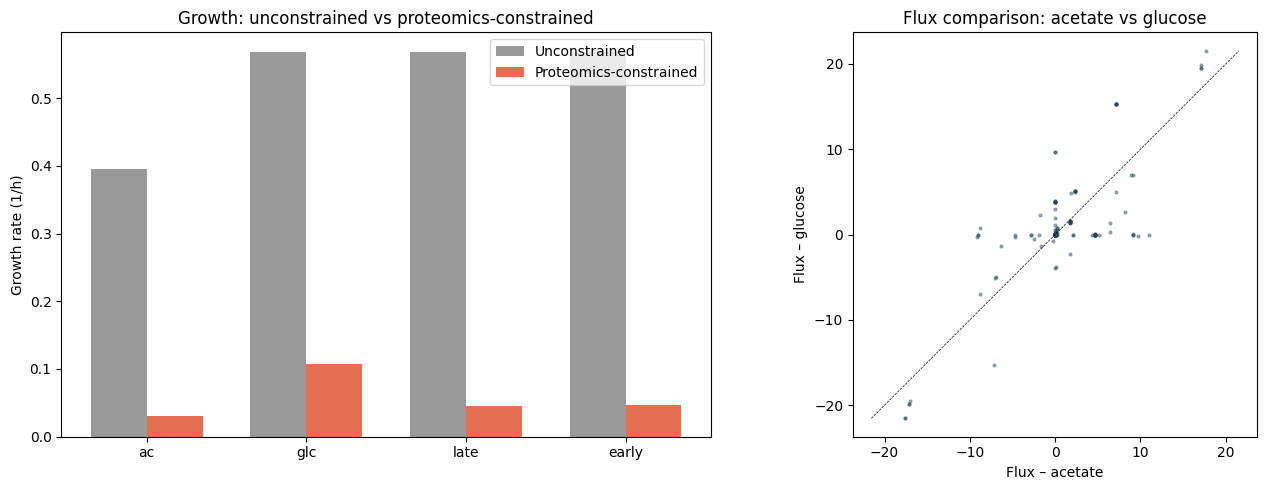

In [29]:
# ── Compare flux distributions across conditions ─────────────────────────────
import matplotlib.pyplot as plt

# Collect full solutions
solutions = {}
for cond in CONDITIONS:
    sol = results[cond]["model"].optimize()
    solutions[cond] = sol.fluxes

flux_df = pd.DataFrame(solutions)
flux_df.columns = [c.replace("DSS3_", "") for c in flux_df.columns]

# Growth comparison: constrained vs unconstrained per condition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cond_labels = [c.replace("DSS3_", "") for c in CONDITIONS]
x = np.arange(len(CONDITIONS))
w = 0.35
constrained_g = [results[c]["growth"] for c in CONDITIONS]
baseline_g = [baselines[c] for c in CONDITIONS]

axes[0].bar(x - w/2, baseline_g, w, label="Unconstrained", color="#999")
axes[0].bar(x + w/2, constrained_g, w, label="Proteomics-constrained", color="#e76f51")
axes[0].set_xticks(x)
axes[0].set_xticklabels(cond_labels)
axes[0].set_ylabel("Growth rate (1/h)")
axes[0].set_title("Growth: unconstrained vs proteomics-constrained")
axes[0].legend()

# Flux correlation between acetate and glucose conditions
ax = axes[1]
shared = flux_df.dropna()
ax.scatter(shared["ac"], shared["glc"], s=4, alpha=0.4, c="#264653")
lim = max(abs(shared[["ac", "glc"]]).max().max(), 1)
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
ax.set_xlabel("Flux – acetate")
ax.set_ylabel("Flux – glucose")
ax.set_title("Flux comparison: acetate vs glucose")
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

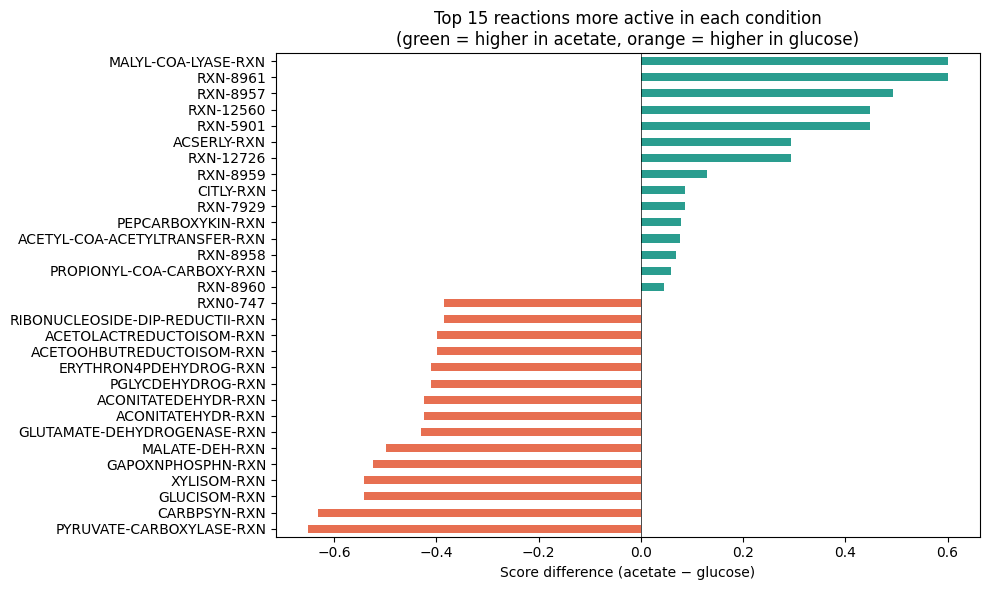

In [30]:
# ── Top differentially constrained reactions (acetate vs glucose) ─────────────
ac_scores = pd.Series(results["DSS3_ac"]["scores"])
glc_scores = pd.Series(results["DSS3_glc"]["scores"])

common = ac_scores.index.intersection(glc_scores.index)
diff = (ac_scores[common] - glc_scores[common]).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
top_n = 15
to_plot = pd.concat([diff.head(top_n), diff.tail(top_n)])
colors = ["#2a9d8f" if v > 0 else "#e76f51" for v in to_plot]
to_plot.plot.barh(ax=ax, color=colors)
ax.set_xlabel("Score difference (acetate − glucose)")
ax.set_title(f"Top {top_n} reactions more active in each condition\n"
             "(green = higher in acetate, orange = higher in glucose)")
ax.axvline(0, color="k", lw=0.5)
fig.tight_layout()
plt.show()

In [12]:
# ── Integrate RNA-seq data (same E-Flux approach) ────────────────────────────
# Use relative RNA abundances as an alternative / complementary constraint layer.

rna_model_genes = rna_rel[rna_rel["SPO_ID (ACCESSION)"].isin(gene_overlap)].copy()
rna_model_genes = rna_model_genes.set_index("SPO_ID (ACCESSION)")

rna_abund = {}
for cond, col in zip(CONDITIONS, RNA_ABUND_COLS):
    series = rna_model_genes[col].dropna()
    rna_abund[cond] = series[series > 0].to_dict()

rna_results = {}
for cond in CONDITIONS:
    cm, scores = proteomics_constrained_model(
        model, rna_abund[cond], medium=MEDIA[cond], label=f"rna_{cond}"
    )
    obj = cm.slim_optimize()
    rna_results[cond] = {"model": cm, "scores": scores, "growth": obj}

# Summary table
summary = pd.DataFrame({
    "baseline_growth":   {c: baselines[c] for c in CONDITIONS},
    "proteomics_growth": {c: results[c]["growth"] for c in CONDITIONS},
    "rna_growth":        {c: rna_results[c]["growth"] for c in CONDITIONS},
    "prot_rxns_scaled":  {c: len(results[c]["scores"]) for c in CONDITIONS},
    "rna_rxns_scaled":   {c: len(rna_results[c]["scores"]) for c in CONDITIONS},
})
summary.index = [c.replace("DSS3_", "") for c in summary.index]
summary

,baseline_growth,proteomics_growth,rna_growth,prot_rxns_scaled,rna_rxns_scaled
ac,0.263281,0.031323,0.082845,671,793
glc,0.568692,0.108047,0.283031,675,793
late,0.568692,0.045849,0.240539,678,793
early,0.568692,0.047364,0.236121,691,793


In [13]:
# ── Multi-omics: combine proteomics + transcriptomics ─────────────────────────
# Use the geometric mean of normalised protein and RNA scores so both layers
# contribute equally.  This is a simple multi-omics integration heuristic.

def multi_omics_constrained_model(model, prot_abund, rna_abund_cond, medium=None, label=""):
    """Constrain model using geometric mean of protein and RNA abundance scores."""
    constrained = model.copy()
    if label:
        constrained.id = f"{model.id}_{label}"
    if medium:
        for rxn_id, bounds in medium.items():
            constrained.reactions.get_by_id(rxn_id).bounds = bounds

    prot_raw, rna_raw = {}, {}
    for rxn in constrained.reactions:
        gpr = rxn.gene_reaction_rule
        ps = _eval_gpr_abundance(gpr, prot_abund)
        rs = _eval_gpr_abundance(gpr, rna_abund_cond)
        if ps is not None:
            prot_raw[rxn.id] = ps
        if rs is not None:
            rna_raw[rxn.id] = rs

    prot_max = max(prot_raw.values()) if prot_raw else 1
    rna_max = max(rna_raw.values()) if rna_raw else 1

    combined = {}
    for rid in set(prot_raw) | set(rna_raw):
        p = prot_raw.get(rid, prot_max) / prot_max
        r = rna_raw.get(rid, rna_max) / rna_max
        combined[rid] = np.sqrt(p * r)  # geometric mean

    for rxn in constrained.reactions:
        if rxn.id in combined:
            s = combined[rxn.id]
            if rxn.upper_bound > 0:
                rxn.upper_bound *= s
            if rxn.lower_bound < 0:
                rxn.lower_bound *= s

    return constrained, combined


multi_results = {}
for cond in CONDITIONS:
    cm, scores = multi_omics_constrained_model(
        model, gene_abund[cond], rna_abund[cond],
        medium=MEDIA[cond], label=f"multi_{cond}"
    )
    obj = cm.slim_optimize()
    multi_results[cond] = {"model": cm, "scores": scores, "growth": obj}

summary["multi_omics_growth"] = {c: multi_results[c]["growth"] for c in CONDITIONS}
summary

,baseline_growth,proteomics_growth,rna_growth,prot_rxns_scaled,rna_rxns_scaled,multi_omics_growth
ac,0.263281,0.031323,0.082845,671,793,NaN
glc,0.568692,0.108047,0.283031,675,793,NaN
late,0.568692,0.045849,0.240539,678,793,NaN
early,0.568692,0.047364,0.236121,691,793,NaN


In [14]:
# ── Relaxed E-Flux (floor on scaling factor) ─────────────────────────────────
# Pure E-Flux can over-constrain when normalising against the single most
# abundant enzyme. Adding a floor (min_scale) prevents low-abundance but
# essential enzymes from being driven to near-zero capacity.
# This mirrors the relaxation idea from geckopy.experimental.relaxation.

def relaxed_eflux_model(model, abund, min_scale=0.05, medium=None, label=""):
    """E-Flux with a floor on the scaling factor.

    min_scale : float in (0, 1] – minimum allowed scaling factor.
    """
    constrained = model.copy()
    if label:
        constrained.id = f"{model.id}_{label}"
    if medium:
        for rxn_id, bounds in medium.items():
            constrained.reactions.get_by_id(rxn_id).bounds = bounds

    raw_scores = {}
    for rxn in constrained.reactions:
        score = _eval_gpr_abundance(rxn.gene_reaction_rule, abund)
        if score is not None:
            raw_scores[rxn.id] = score

    if not raw_scores:
        return constrained, {}

    max_score = max(raw_scores.values()) or 1.0
    norm_scores = {
        rid: max(min_scale, s / max_score) for rid, s in raw_scores.items()
    }

    for rxn in constrained.reactions:
        if rxn.id in norm_scores:
            s = norm_scores[rxn.id]
            if rxn.upper_bound > 0:
                rxn.upper_bound *= s
            if rxn.lower_bound < 0:
                rxn.lower_bound *= s

    return constrained, norm_scores


relaxed_results = {}
for cond in CONDITIONS:
    cm, scores = relaxed_eflux_model(
        model, gene_abund[cond], min_scale=0.005,
        medium=MEDIA[cond], label=f"relaxed_{cond}"
    )
    obj = cm.slim_optimize()
    relaxed_results[cond] = {"model": cm, "scores": scores, "growth": obj}
    print(f"{cond:15s}  relaxed E-Flux growth = {obj:.6f}  "
          f"(baseline = {baselines[cond]:.6f})")

DSS3_ac          relaxed E-Flux growth = 0.181513  (baseline = 0.263281)
DSS3_glc         relaxed E-Flux growth = 0.288623  (baseline = 0.568692)
DSS3_late        relaxed E-Flux growth = 0.286728  (baseline = 0.568692)
DSS3_early       relaxed E-Flux growth = 0.288623  (baseline = 0.568692)


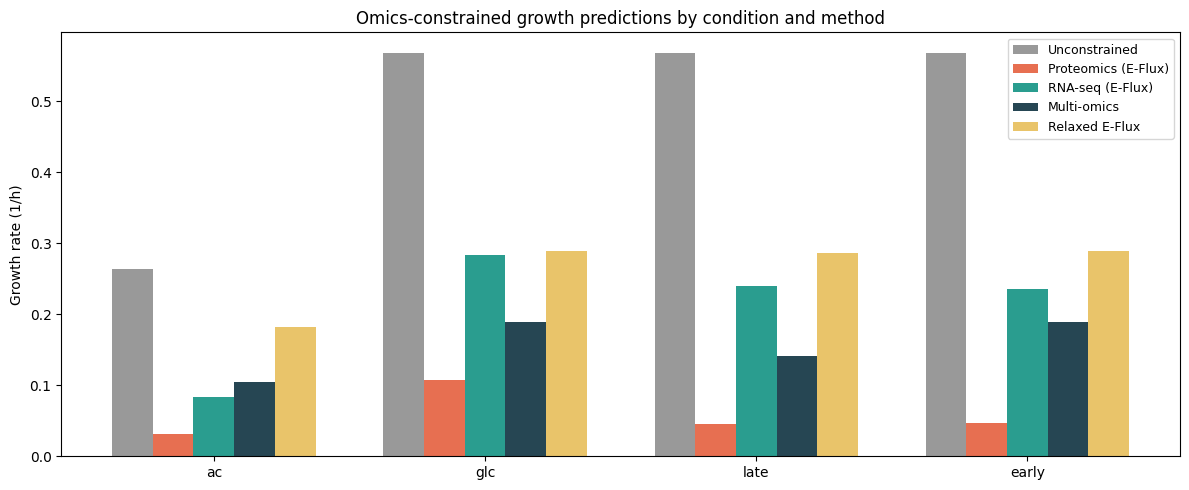

In [15]:
# ── Final comparison plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

cond_labels = [c.replace("DSS3_", "") for c in CONDITIONS]
x = np.arange(len(CONDITIONS))
w = 0.15

base_g    = [baselines[c] for c in CONDITIONS]
prot_g    = [results[c]["growth"] for c in CONDITIONS]
rna_g     = [rna_results[c]["growth"] for c in CONDITIONS]
multi_g   = [multi_results[c]["growth"] for c in CONDITIONS]
relaxed_g = [relaxed_results[c]["growth"] for c in CONDITIONS]

ax.bar(x - 2*w, base_g,    w, label="Unconstrained",       color="#999")
ax.bar(x - 1*w, prot_g,    w, label="Proteomics (E-Flux)", color="#e76f51")
ax.bar(x + 0*w, rna_g,     w, label="RNA-seq (E-Flux)",    color="#2a9d8f")
ax.bar(x + 1*w, multi_g,   w, label="Multi-omics",         color="#264653")
ax.bar(x + 2*w, relaxed_g, w, label="Relaxed E-Flux",      color="#e9c46a")

ax.set_xticks(x)
ax.set_xticklabels(cond_labels)
ax.set_ylabel("Growth rate (1/h)")
ax.set_title("Omics-constrained growth predictions by condition and method")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

Using GECKO

In [31]:
import geckopy
from geckopy.reaction import Reaction as ECReaction

ModuleNotFoundError: No module named 'geckopy.reaction'

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Dict, Iterable, List, Optional, Sequence, Set, Tuple, FrozenSet
import cobra
from cobra.core.gene import GPR
import ast

def _dnf_from_gpr_ast(node) -> List[FrozenSet[str]]:
    """
    Convert a COBRApy-parsed GPR AST into Disjunctive Normal Form (DNF).

    Returns a list of "variants"; each variant is a frozenset of genes that are AND'ed together.
    The overall list is OR'ed together.

    Examples:
        "A"                 -> [{A}]
        "A and B"           -> [{A,B}]
        "A or B"            -> [{A}, {B}]
        "(A and B) or C"    -> [{A,B}, {C}]
        "A and (B or C)"    -> [{A,B}, {A,C}]
    """
    if isinstance(node, ast.Name):
        return [frozenset([node.id])]

    if isinstance(node, ast.BoolOp):
        child_dnfs = [_dnf_from_gpr_ast(c) for c in node.values]

        if isinstance(node.op, ast.Or):
            out: List[FrozenSet[str]] = []
            for d in child_dnfs:
                out.extend(d)
            # deduplicate while preserving order
            seen = set()
            uniq = []
            for v in out:
                if v not in seen:
                    uniq.append(v)
                    seen.add(v)
            return uniq

        if isinstance(node.op, ast.And):
            # cartesian product of variants
            acc: List[FrozenSet[str]] = [frozenset()]
            for d in child_dnfs:
                new_acc: List[FrozenSet[str]] = []
                for a in acc:
                    for b in d:
                        new_acc.append(a.union(b))
                acc = new_acc
            # deduplicate
            seen = set()
            uniq = []
            for v in acc:
                if v not in seen:
                    uniq.append(v)
                    seen.add(v)
            return uniq

    if hasattr(node, "body"):
        return _dnf_from_gpr_ast(node.body)

    return []


def gpr_to_variants(gpr_rule: str) -> List[FrozenSet[str]]:
    """
    Parse a gene_reaction_rule string into OR-of-AND variants (DNF).
    """
    if not gpr_rule or not gpr_rule.strip():
        return []
    tree = GPR.from_string(gpr_rule.strip())
    return _dnf_from_gpr_ast(tree.body)


# -----------------------------
# 2) ecModel builder
# -----------------------------

@dataclass(frozen=True)
class IsozymeCopyNaming:
    """
    How to name split reactions for OR variants.
    """
    sep: str = "__E"  # rxn_id + sep + index, e.g. RXN__E1, RXN__E2


def build_ec_model_geckopy(
    gem: cobra.Model,
    kcat_lookup: Callable[[str, str, FrozenSet[str]], float],
    gene_to_protein: Optional[Dict[str, str]] = None,
    protein_prefix: str = "prot_",
    split_isozymes: bool = True,
    naming: IsozymeCopyNaming = IsozymeCopyNaming(),
    default_protein_concentration: Optional[float] = None,
) -> "geckopy.Model":
    """
    Build a GECKO-style enzyme-constrained model (ecModel) using GECKOpy objects.

    Parameters
    ----------
    gem : cobra.Model
        Your standard GEM.
    kcat_lookup : callable
        Function returning kcat (1/s) given (rxn_id, prot_id, genes_variant).
    gene_to_protein : dict, optional
        Map from GEM gene IDs to protein IDs (e.g., UniProt).
        If None, protein id becomes "prot_{gene_id}".
    protein_prefix : str
        Prefix to apply to protein IDs used in the ecModel.
    split_isozymes : bool
        If True, split OR rules into multiple reaction copies, one per variant.
        This is the standard GECKO encoding for isozymes. :contentReference[oaicite:3]{index=3}
    default_protein_concentration : float, optional
        If provided, set Protein.concentration for newly added proteins.
        (Units expected by GECKOpy are typically mmol/gDW; if you don't have absolute
         concentrations, leave None and later apply proteomics properly.)

    Returns
    -------
    ec_model : geckopy.Model
    """
    try:
        import geckopy
        from geckopy.reaction import Reaction as ECReaction
    except ImportError as e:
        raise ImportError(
            "geckopy is not installed. Install with: pip install geckopy"
        ) from e

    # Create an empty GECKOpy Model
    ec_model = geckopy.Model(gem.id)
    ec_model.name = getattr(gem, "name", None)

    # 1) Copy metabolites first
    met_map: Dict[str, cobra.Metabolite] = {}
    for m in gem.metabolites:
        m2 = cobra.Metabolite(
            id=m.id,
            name=m.name,
            formula=getattr(m, "formula", None),
            charge=getattr(m, "charge", None),
            compartment=m.compartment,
        )
        m2.annotation = dict(getattr(m, "annotation", {}) or {})
        m2.notes = dict(getattr(m, "notes", {}) or {})
        met_map[m.id] = m2
    ec_model.add_metabolites(list(met_map.values()))

    # Helper: map a gene id -> protein id used in ecModel
    def gene_to_prot_id(g: str) -> str:
        pid = (gene_to_protein.get(g) if gene_to_protein else None) or g
        if not pid.startswith(protein_prefix):
            pid = protein_prefix + pid
        return pid

    # 2) Copy reactions + add enzyme constraints
    # We'll keep track if a reaction was split, to adjust objective coefficients cleanly.
    objective_coeffs = cobra.util.solver.linear_reaction_coefficients(gem)

    for rxn in gem.reactions:
        variants = gpr_to_variants(rxn.gene_reaction_rule)

        # Make a base reaction copy constructor
        def make_rxn_copy(new_id: str) -> "geckopy.reaction.Reaction":
            r2 = ECReaction(new_id)
            r2.name = rxn.name
            r2.subsystem = rxn.subsystem
            r2.lower_bound = rxn.lower_bound
            r2.upper_bound = rxn.upper_bound
            r2.gene_reaction_rule = rxn.gene_reaction_rule
            r2.annotation = dict(getattr(rxn, "annotation", {}) or {})
            r2.notes = dict(getattr(rxn, "notes", {}) or {})

            # stoichiometry
            stoich = {met_map[m.id]: coeff for m, coeff in rxn.metabolites.items()}
            r2.add_metabolites(stoich)
            return r2

        if split_isozymes and len(variants) >= 2:
            # Disable the original reaction in ec_model by not adding it,
            # and instead add one copy per isozyme variant (OR).
            # This matches typical GECKO encodings for isozymes. :contentReference[oaicite:4]{index=4}
            copies: List["geckopy.reaction.Reaction"] = []

            for i, genes_variant in enumerate(variants, start=1):
                new_id = f"{rxn.id}{naming.sep}{i}"
                r2 = make_rxn_copy(new_id)

                # Add enzyme constraints for this variant (AND set)
                for g in genes_variant:
                    prot_id = gene_to_prot_id(g)
                    kcat = float(kcat_lookup(rxn.id, prot_id, genes_variant))
                    if kcat <= 0:
                        raise ValueError(f"kcat must be >0 for {rxn.id}, {prot_id}. Got {kcat}.")

                    # GECKOpy stores enzyme usage via a protein pseudo-metabolite
                    # with coefficient -1/(kcat*3600) where kcat is 1/s. :contentReference[oaicite:5]{index=5}
                    r2.add_protein(
                        id=prot_id,
                        kcat=kcat,
                        concentration=default_protein_concentration,
                        name=prot_id,
                    )

                copies.append(r2)

            ec_model.add_reactions(copies)

            # If the original rxn had objective weight, distribute it across copies
            w = objective_coeffs.get(rxn, 0.0)
            if w:
                for r2 in copies:
                    r2.objective_coefficient = w

        else:
            # Single variant (or no GPR): keep one reaction copy
            r2 = make_rxn_copy(rxn.id)
            ec_model.add_reactions([r2])

            if variants:
                # For AND rule (complex): add all subunits as proteins to same reaction.
                # (This yields "must satisfy each subunit constraint" behavior.)
                # For OR rule with split_isozymes=False, we conservatively add ALL proteins,
                # which behaves like AND (over-constraining). Prefer split_isozymes=True.
                genes_variant = variants[0]  # if OR exists and not splitting, we pick first
                for g in genes_variant:
                    prot_id = gene_to_prot_id(g)
                    kcat = float(kcat_lookup(rxn.id, prot_id, genes_variant))
                    if kcat <= 0:
                        raise ValueError(f"kcat must be >0 for {rxn.id}, {prot_id}. Got {kcat}.")
                    r2.add_protein(
                        id=prot_id,
                        kcat=kcat,
                        concentration=default_protein_concentration,
                        name=prot_id,
                    )

            # Carry over objective coefficient if present
            w = objective_coeffs.get(rxn, 0.0)
            if w:
                r2.objective_coefficient = w

    return ec_model


# -----------------------------
# 3) Example usage
# -----------------------------

if __name__ == "__main__":
    from cobra.io import read_sbml_model

    gem = read_sbml_model("../model/Rpom_05.xml")

    # EXAMPLE kcat provider:
    # Replace this with your real kcat table lookup.
    # For now, use a single conservative default (e.g., 100 1/s) everywhere.
    def kcat_lookup(rxn_id: str, prot_id: str, genes_variant: FrozenSet[str]) -> float:
        return 100.0  # 1/s (placeholder!)

    # Optional: if you have UniProt mapping, pass gene_to_protein={"SPO_RS03695": "P0A796", ...}
    ec = build_ec_model_geckopy(
        gem,
        kcat_lookup=kcat_lookup,
        gene_to_protein=None,
        split_isozymes=True,
        default_protein_concentration=None,  # set later from proteomics
    )

    print(ec)
    print("Objective:", ec.objective)
    print("Growth:", ec.slim_optimize())

ImportError: geckopy is not installed. Install with: pip install geckopy